In [1]:
!pip install -q numpy matplotlib scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 10.0 MB/s eta 0:00:00


       SISTEMA FUZZY DE IRRIGAÇÃO INTELIGENTE
Digite a temperatura ambiente (0 a 40 °C): 35
Digite a umidade do solo (0 a 100%): 58

                    RESULTADO
Temperatura: 35.0 °C
Umidade do solo: 58.0%
Tempo recomendado de irrigação: 13.4 minutos


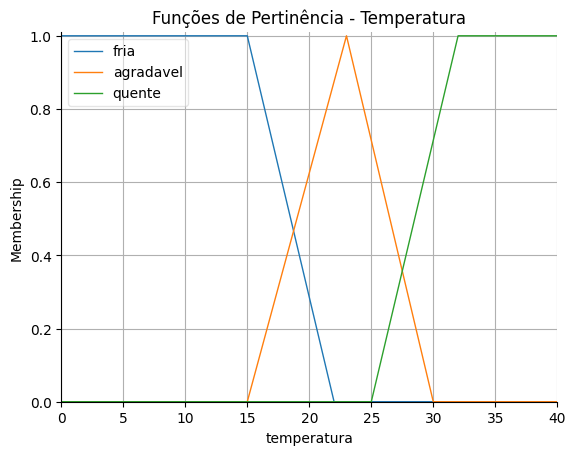

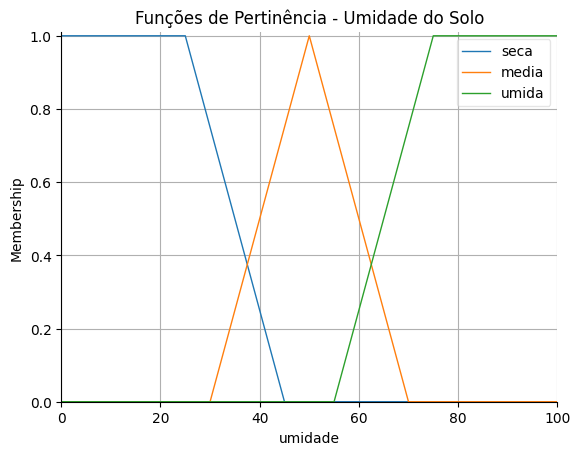

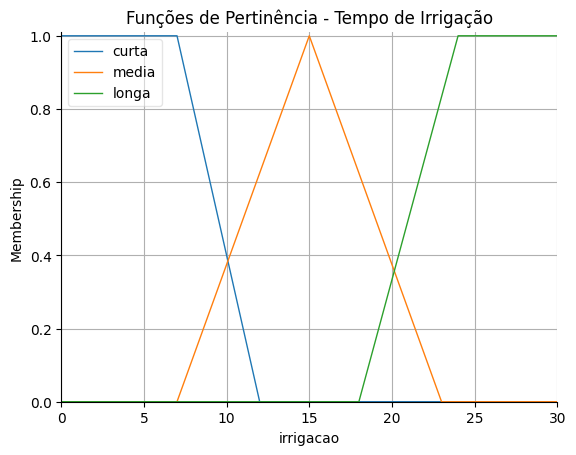



                    TESTES DO SISTEMA
Temperatura: 35 °C | Umidade:  20% | Irrigação: 25.33 min
Temperatura: 25 °C | Umidade:  50% | Irrigação: 15.00 min
Temperatura: 15 °C | Umidade:  80% | Irrigação: 4.86 min
Temperatura: 30 °C | Umidade:  65% | Irrigação: 9.14 min

CONCLUSÃO





In [2]:
# ==============================================================================
# AULA 09 - PROJETO DE LÓGICA FUZZY
# SISTEMA INTELIGENTE DE IRRIGAÇÃO
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl


# ==============================================================================
# 1. VARIÁVEIS
# ==============================================================================

# Temperatura: 0 até 40 °C
temperatura = ctrl.Antecedent(
    np.arange(0, 41, 1),
    "temperatura"
)

# Umidade do solo: 0 até 100%
umidade = ctrl.Antecedent(
    np.arange(0, 101, 1),
    "umidade"
)

# Tempo de irrigação: 0 até 30 minutos
irrigacao = ctrl.Consequent(
    np.arange(0, 31, 1),
    "irrigacao"
)


# ==============================================================================
# 2. FUNÇÕES DE PERTINÊNCIA - TEMPERATURA
# ==============================================================================

temperatura["fria"] = fuzz.trapmf(
    temperatura.universe,
    [0, 0, 15, 22]
)

temperatura["agradavel"] = fuzz.trimf(
    temperatura.universe,
    [15, 23, 30]
)

temperatura["quente"] = fuzz.trapmf(
    temperatura.universe,
    [25, 32, 40, 40]
)


# ==============================================================================
# 3. FUNÇÕES DE PERTINÊNCIA - UMIDADE
# ==============================================================================

umidade["seca"] = fuzz.trapmf(
    umidade.universe,
    [0, 0, 25, 45]
)

umidade["media"] = fuzz.trimf(
    umidade.universe,
    [30, 50, 70]
)

umidade["umida"] = fuzz.trapmf(
    umidade.universe,
    [55, 75, 100, 100]
)


# ==============================================================================
# 4. FUNÇÕES DE PERTINÊNCIA - IRRIGAÇÃO
# ==============================================================================

irrigacao["curta"] = fuzz.trapmf(
    irrigacao.universe,
    [0, 0, 7, 12]
)

irrigacao["media"] = fuzz.trimf(
    irrigacao.universe,
    [7, 15, 23]
)

irrigacao["longa"] = fuzz.trapmf(
    irrigacao.universe,
    [18, 24, 30, 30]
)


# ==============================================================================
# 5. REGRAS FUZZY
# ==============================================================================

regra1 = ctrl.Rule(
    umidade["seca"] & temperatura["quente"],
    irrigacao["longa"]
)

regra2 = ctrl.Rule(
    umidade["seca"] & temperatura["agradavel"],
    irrigacao["longa"]
)

regra3 = ctrl.Rule(
    umidade["seca"] & temperatura["fria"],
    irrigacao["media"]
)

regra4 = ctrl.Rule(
    umidade["media"] & temperatura["quente"],
    irrigacao["media"]
)

regra5 = ctrl.Rule(
    umidade["media"] & temperatura["agradavel"],
    irrigacao["media"]
)

regra6 = ctrl.Rule(
    umidade["media"] & temperatura["fria"],
    irrigacao["curta"]
)

regra7 = ctrl.Rule(
    umidade["umida"] & temperatura["quente"],
    irrigacao["curta"]
)

regra8 = ctrl.Rule(
    umidade["umida"] & temperatura["agradavel"],
    irrigacao["curta"]
)

# Regra utilizando OU
regra9 = ctrl.Rule(
    umidade["umida"] | temperatura["fria"],
    irrigacao["curta"]
)


# ==============================================================================
# 6. SISTEMA DE CONTROLE
# ==============================================================================

sistema = ctrl.ControlSystem([
    regra1,
    regra2,
    regra3,
    regra4,
    regra5,
    regra6,
    regra7,
    regra8,
    regra9
])


# ==============================================================================
# 7. FUNÇÃO PARA EXECUTAR O SISTEMA
# ==============================================================================

def calcular_irrigacao(temp, umid):

    simulacao = ctrl.ControlSystemSimulation(sistema)

    simulacao.input["temperatura"] = temp
    simulacao.input["umidade"] = umid

    simulacao.compute()

    return simulacao.output["irrigacao"]


# ==============================================================================
# 8. TESTE INTERATIVO
# ==============================================================================

print("=" * 60)
print("       SISTEMA FUZZY DE IRRIGAÇÃO INTELIGENTE")
print("=" * 60)

temp = float(
    input("Digite a temperatura ambiente (0 a 40 °C): ")
)

umid = float(
    input("Digite a umidade do solo (0 a 100%): ")
)

resultado = calcular_irrigacao(temp, umid)

print("\n" + "=" * 60)
print("                    RESULTADO")
print("=" * 60)

print(f"Temperatura: {temp:.1f} °C")
print(f"Umidade do solo: {umid:.1f}%")
print(f"Tempo recomendado de irrigação: {resultado:.1f} minutos")


# ==============================================================================
# 9. GRÁFICOS DAS FUNÇÕES DE PERTINÊNCIA
# ==============================================================================

temperatura.view()
plt.title("Funções de Pertinência - Temperatura")
plt.grid()
plt.show()

umidade.view()
plt.title("Funções de Pertinência - Umidade do Solo")
plt.grid()
plt.show()

irrigacao.view()
plt.title("Funções de Pertinência - Tempo de Irrigação")
plt.grid()
plt.show()


# ==============================================================================
# 10. TESTES AUTOMÁTICOS
# ==============================================================================

testes = [
    (35, 20),
    (25, 50),
    (15, 80),
    (30, 65)
]

print("\n")
print("=" * 70)
print("                    TESTES DO SISTEMA")
print("=" * 70)

for temp_teste, umid_teste in testes:

    resultado_teste = calcular_irrigacao(
        temp_teste,
        umid_teste
    )

    print(
        f"Temperatura: {temp_teste:2d} °C | "
        f"Umidade: {umid_teste:3d}% | "
        f"Irrigação: {resultado_teste:.2f} min"
    )


# ==============================================================================
# 11. CONCLUSÃO
# ==============================================================================

print("\n" + "=" * 70)
print("CONCLUSÃO")
print("=" * 70)

print("""

""")